<a href="https://colab.research.google.com/github/JohnYechanJo/3D-Brain-Tumor-Segmentation/blob/main/3D_Brain_Tumor_Segmentation_EDA_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1.3 Image & mask visulization
* 다른 Notebook에서는 어떻게 image를 visulization을 했는지도 살펴보며 실습을 해보도록 하겠습니다.  

In [ ]:
## reference : https://www.kaggle.com/code/mariuszwisniewski/brats2020-eda-and-data-visualization/notebook
from matplotlib import animation, cm, colors, rc
import matplotlib.patches as mpatches

DATA_TYPES = ['flair', 't1', 't1ce', 't2', 'mask']
MASK_LABELS = ['Non-Enhancing Tumor Core',
               'Peritumoral Edema', 'GD-Enhancing Tumor']
MASK_VALUES = [0, 1, 2, 4]
def cmap_discretize(cmap, N):
    """Return a discrete colormap from the continuous colormap cmap.

        cmap: colormap instance, eg. cm.jet.
        N: number of colors.
    """
    if type(cmap) == str:
        cmap = plt.get_cmap(cmap)
    colors_i = np.concatenate((np.linspace(0, 1., N), (0., 0., 0., 0.)))
    colors_rgba = cmap(colors_i)
    indices = np.linspace(0, 1., N+1)
    cdict = {}
    for ki, key in enumerate(('red', 'green', 'blue')):
        cdict[key] = [(indices[i], colors_rgba[i-1, ki],
                       colors_rgba[i, ki]) for i in range(N+1)]
    return colors.LinearSegmentedColormap(cmap.name + "_%d" % N, cdict, 1024)


rc('animation', html='jshtml')


def create_parallel_animation(volumes, case, show_mask=False, alpha=0.6):
    """Create animation of multiple volumes"""
    # transpose volume from (x, y, z) to (z, x, y)
    volumes = np.array([np.transpose(volume, (2, 0, 1)) for volume in volumes])
    fig = plt.figure(figsize=(12, 13))
    fig.tight_layout()
    plt.axis('off')
    plt.suptitle(f'Patient ID: {case}', fontsize=16, fontweight='bold')

    if show_mask: ## mask에 Color를 넣어준다.
        custom_cmap = cmap_discretize(cm.jet, int(np.max(volumes[-1])) + 1)
        normalize = colors.Normalize(vmin=np.min(
            volumes[-1]), vmax=np.max(volumes[-1]))

    axes = []
    for idx, data_type in enumerate(DATA_TYPES[:-1]): # image에 넣을 figure를 만들어준다.
        ax = fig.add_subplot(2, len(DATA_TYPES[:-1]) // 2, idx + 1)
        ax.set_title(data_type.upper(), weight='bold')
        axes.append(ax)

    images = []
    for i, slices in enumerate(zip(*volumes[:-1])): # 한장씩 loop를 돌면서 image를 쌓아준다.
        aux_imgs = []
        for idx, s in enumerate(slices):
            im = axes[idx].imshow(s, animated=True, cmap='bone')
            aux_imgs.append(im)
            if show_mask:
                im2 = axes[idx].imshow(np.ma.masked_where(volumes[-1][i] == 0, volumes[-1][i]),
                                       animated=True, cmap=custom_cmap, alpha=alpha, interpolation='none')
                aux_imgs.append(im2)
        images.append(aux_imgs)

    if show_mask:
        print(np.unique(volumes[-1])[1:])
        patches = [mpatches.Patch(color=custom_cmap(normalize(col_val)),
                                  label=f'{MASK_LABELS[l_idx]}') for l_idx, col_val in enumerate(np.unique(volumes[-1])[1:])]
        plt.legend(handles=patches, loc='upper left', bbox_to_anchor=(0.4, -0.1), borderaxespad=0.4,
                   title='Mask Labels', title_fontsize=18, edgecolor='black', facecolor='#c5c6c7')

    ani = animation.ArtistAnimation(
        fig, images, interval=5000 // len(images), blit=False, repeat_delay=1000
    )
    plt.close()
    return ani

## 1.4 Image & mask visulization

In [ ]:
from monai.data import DataLoader, decollate_batch, Dataset
from scipy import ndimage
from monai.transforms import (
    LoadImaged,
    EnsureChannelFirstd,
    Compose,
    NormalizeIntensityd
)
from monai.visualize.utils import (
    blend_images,## label과 Image를 합친 영상
    matshow3d ## 3d image의 visulization
)

In [ ]:
data_dicts = []
for images_path, mask_path in zip(merge_df[['flair','t1','t1ce','t2']].values, merge_df['mask'].values):
    data_dicts.append({
            'image':images_path,
            'label':[mask_path]}
            )

In [ ]:
train_transform = Compose(
    [
        # load 4 Nifti images and stack them together
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys="image"),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    ])

In [ ]:
train_dataset = Dataset(data_dicts, transform=train_transform)

image shape: torch.Size([4, 240, 240, 155])
label shape: torch.Size([240, 240, 155])
pixel spacing: tensor([1., 1., 1.], dtype=torch.float64)


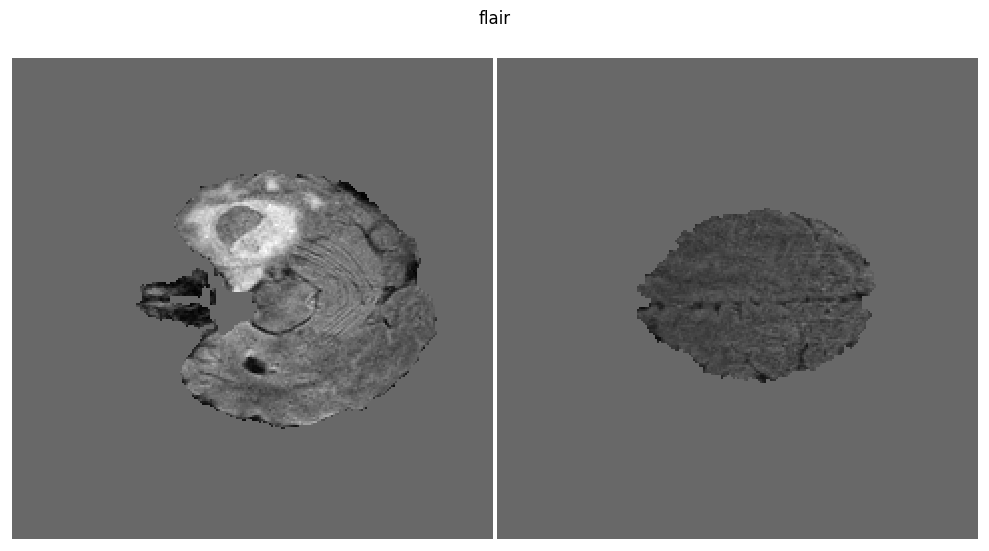

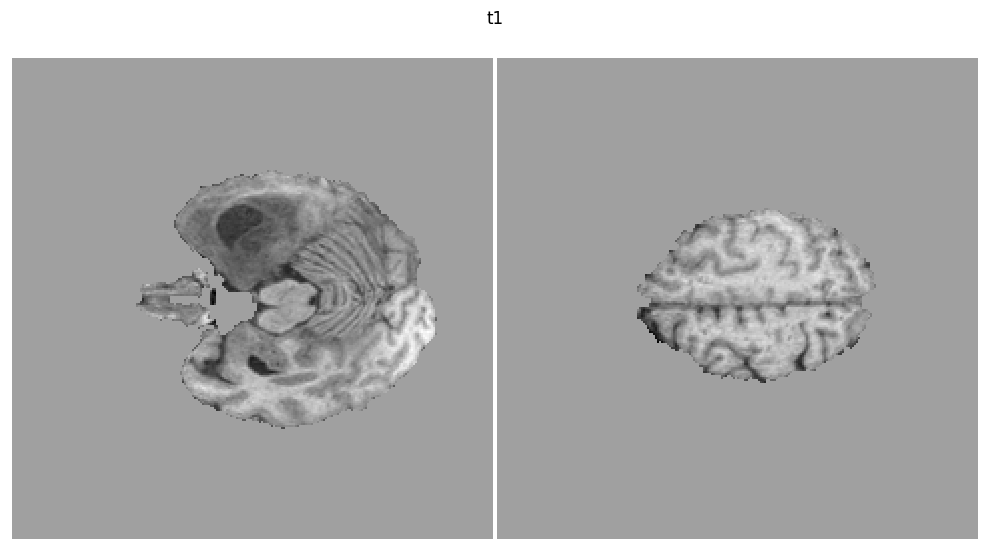

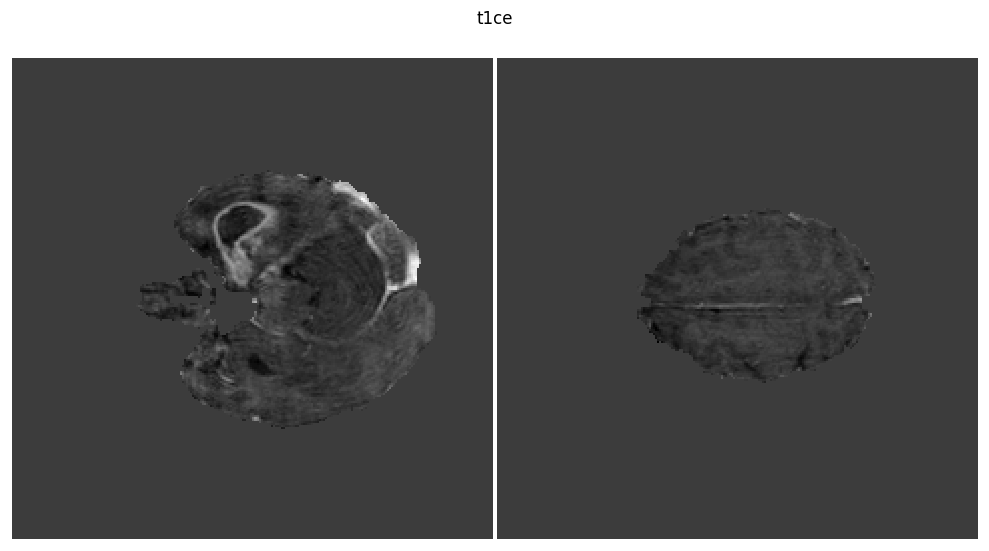

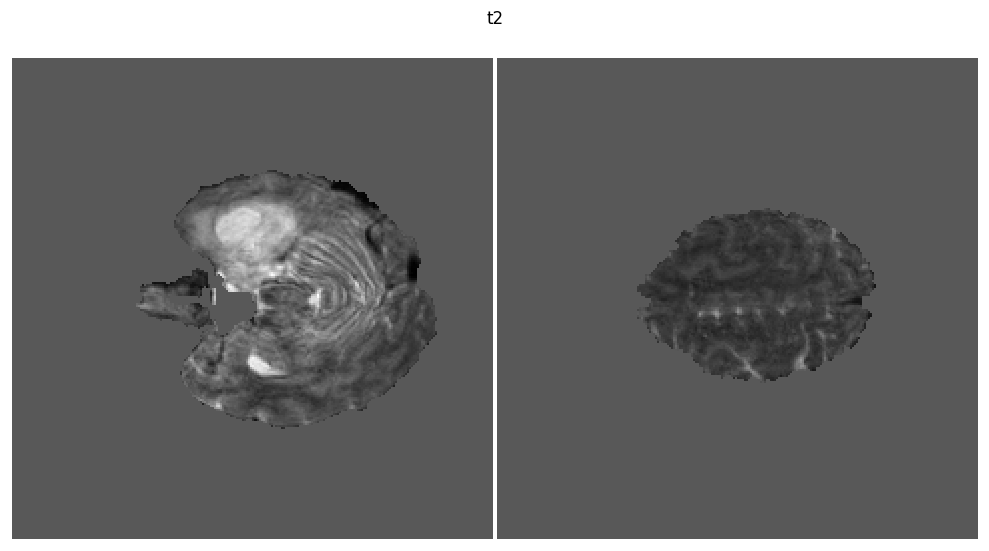

In [ ]:
print(f"image shape: {train_dataset[0]['image'].shape}")
print(f"label shape: {train_dataset[0]['label'].shape}")
print(f"pixel spacing: {train_dataset[0]['image'].pixdim}")
for img, title in zip(train_dataset[0]["image"], ['flair','t1','t1ce','t2']):
    _ = matshow3d(
    volume=img[...,50::70],
    fig=None,
    title=title,
    frame_dim=-1,
    show=True,
    cmap="gray",)

In [ ]:
train_transform = Compose(
    [
        # load 4 Nifti images and stack them together
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys="image"),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    ])

In [ ]:
(train_dataset[0]["label"][None]==1).max()

metatensor(True)

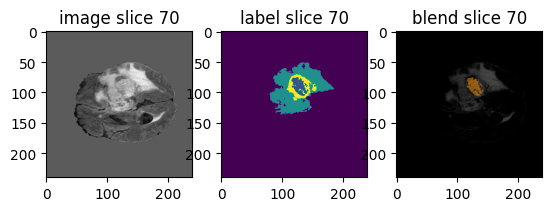

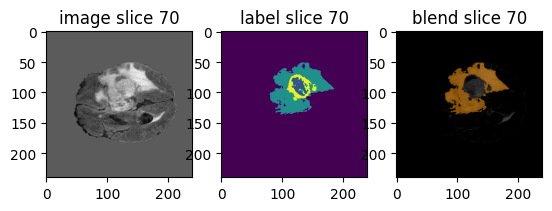

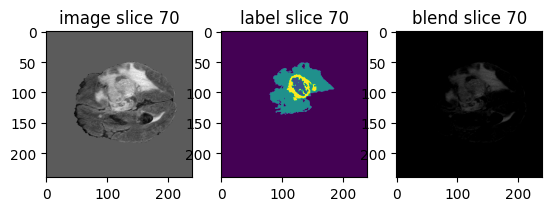

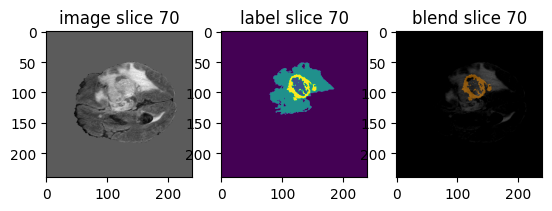

In [ ]:
import matplotlib.pyplot as plt
import torch
for i in range(4):
    if i != 4:
        norm_img = train_dataset[0]["image"][[0]]/train_dataset[0]["image"].max()
        norm_lab = (train_dataset[0]["label"][None]==(i+1))*0.1
        ret = blend_images(image=norm_img, label=norm_lab, alpha=0.5, cmap="hsv", rescale_arrays=False)
        fig,axs = plt.subplots(1,3)
        slice_index = 70
        axs[0].set_title(f"image slice {slice_index}")
        axs[0].imshow(train_dataset[0]["image"][0, :, :, slice_index], cmap="gray")
        axs[1].set_title(f"label slice {slice_index}")
        axs[1].imshow(train_dataset[0]["label"][:, :, slice_index])
        axs[2].set_title(f"blend slice {slice_index}")
        axs[2].imshow(torch.moveaxis(ret[:, :, :, slice_index], 0, -1))